In [1]:
import os
import matplotlib.pyplot as plt
import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Temizlenmiş Veri Setini Yükleme
bundle = joblib.load("../backend/models/bankloan/bankloan_data_bundle.pkl")

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]

print("Veriler başarıyla yüklendi!")
print(f"X_train boyutu: {X_train.shape}, X_test boyutu: {X_test.shape}")

Veriler başarıyla yüklendi!
X_train boyutu: (4000, 5), X_test boyutu: (1000, 5)


In [2]:
# Modeli Tanımlama
rf_model = RandomForestClassifier(
    n_estimators=250,
    min_samples_split=4,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
)

In [3]:
# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="accuracy")

print("K-Fold (5 Katlı) Doğrulama Skorları:", cv_scores)
print("Ortalama CV Doğruluğu: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

K-Fold (5 Katlı) Doğrulama Skorları: [0.98375 0.9825  0.98    0.98375 0.98125]
Ortalama CV Doğruluğu: 0.9822 (+/- 0.0029)


In [4]:
# Tüm Eğitim Verisiyle Modeli Son Kez Eğitme
rf_model.fit(X_train, y_train)
print("\nModel tüm eğitim setiyle son kez eğitildi!")


Model tüm eğitim setiyle son kez eğitildi!


In [5]:
# Train Seti Performansı (Overfitting kontrolü için)
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=" * 40)
print("          TRAIN SETİ PERFORMANSI          ")
print("=" * 40)
print(f"Train Doğruluk Oranı (Accuracy): {train_accuracy:.4f}\n")
print("Train Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred))

# Test Seti Performansı (Gerçek başarı)
y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 40)
print("          TEST SETİ PERFORMANSI           ")
print("=" * 40)
print(f"Test Doğruluk Oranı (Accuracy): {test_accuracy:.4f}\n")
print("Test Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred))

          TRAIN SETİ PERFORMANSI          
Train Doğruluk Oranı (Accuracy): 0.9915

Train Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3616
           1       0.99      0.92      0.95       384

    accuracy                           0.99      4000
   macro avg       0.99      0.96      0.97      4000
weighted avg       0.99      0.99      0.99      4000

          TEST SETİ PERFORMANSI           
Test Doğruluk Oranı (Accuracy): 0.9900

Test Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       904
           1       0.95      0.95      0.95        96

    accuracy                           0.99      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000



In [6]:
# Nihai Modeli Backend Altına Kaydetme
joblib.dump(rf_model, "../backend/models/bankloan/random_forest_model.pkl")
print("Eğitilmiş model başarıyla kaydedildi!")

Eğitilmiş model başarıyla kaydedildi!


In [7]:
# 1. Orijinal ham CSV dosyasını doğrudan oku
df = pd.read_csv("../datasets/bankloan.csv")  # Yolunu kendi klasörüne göre ayarlarsın

# 2. X ve y olarak ayır
X = df.drop(
    "Personal.Loan", axis=1
)  # Kendi hedef sütun adını yazmalısın
y = df["Personal.Loan"]

# 3. Train-Test olarak böl (Analiz notebook'undaki test_size ve random_state AYNİ olmalı!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ham veri yüklendi ve bölündü!")

# 4. Modeli ham veriyle eğit
rf_raw_model = RandomForestClassifier(
    n_estimators=250,
    min_samples_split=4,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
)
rf_raw_model.fit(X_train_raw, y_train)

# 5. Ham Model İçin Train Seti Performansı
y_train_pred_raw = rf_raw_model.predict(X_train_raw)
train_accuracy_raw = accuracy_score(y_train, y_train_pred_raw)

print("=" * 40)
print("      HAM VERİ - TRAIN SETİ PERFORMANSI      ")
print("=" * 40)
print(f"Train Doğruluk Oranı (Accuracy): {train_accuracy_raw:.4f}\n")
print("Train Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred_raw))

# 6. Ham Model İçin Test Seti Performansı (Gerçek başarı)
y_test_pred_raw = rf_raw_model.predict(X_test_raw)
test_accuracy_raw = accuracy_score(y_test, y_test_pred_raw)

print("=" * 40)
print("      HAM VERİ - TEST SETİ PERFORMANSI       ")
print("=" * 40)
print(f"Test Doğruluk Oranı (Accuracy): {test_accuracy_raw:.4f}\n")
print("Test Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred_raw))

Ham veri yüklendi ve bölündü!
      HAM VERİ - TRAIN SETİ PERFORMANSI      
Train Doğruluk Oranı (Accuracy): 0.9938

Train Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3625
           1       1.00      0.94      0.97       375

    accuracy                           0.99      4000
   macro avg       1.00      0.97      0.98      4000
weighted avg       0.99      0.99      0.99      4000

      HAM VERİ - TEST SETİ PERFORMANSI       
Test Doğruluk Oranı (Accuracy): 0.9890

Test Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       895
           1       0.99      0.90      0.95       105

    accuracy                           0.99      1000
   macro avg       0.99      0.95      0.97      1000
weighted avg       0.99      0.99      0.99      1000



--- Öznitelik Önem Düzeyleri ---
     Feature  Importance
0     Income    0.392231
2  Education    0.258272
1      CCAvg    0.167982
4     Family    0.155001
3   Mortgage    0.026514


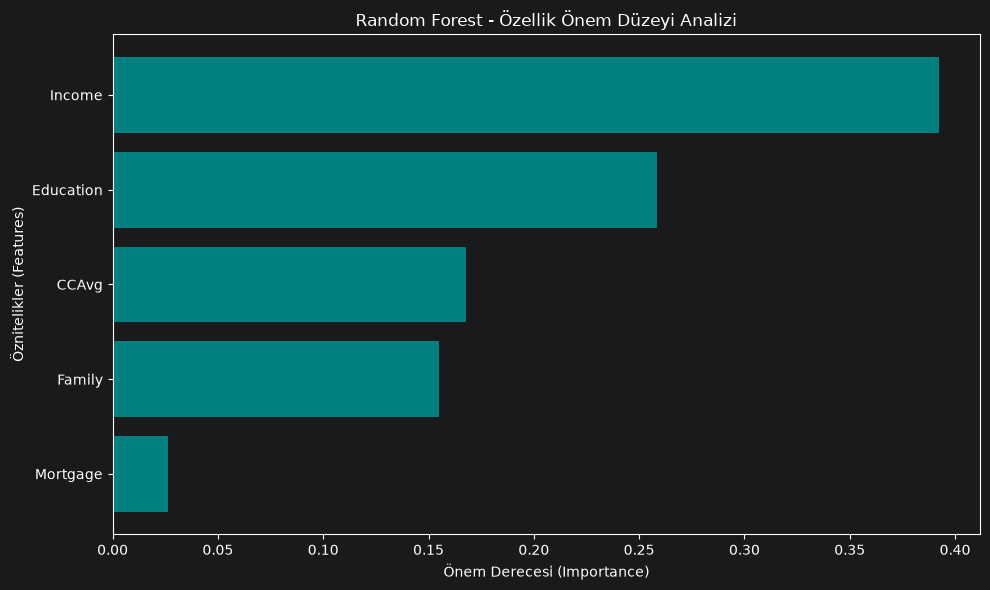

In [8]:
# 1. Özellik önem derecelerini modelden çekelim
importances = rf_model.feature_importances_
feature_names = (
    X_train.columns
)  # X_train hangi sütunlarla eğitildiyse onların adını alır

# 2. DataFrame'e dönüştürüp büyükten küçüğe sıralayalım
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

print("--- Öznitelik Önem Düzeyleri ---")
print(feature_imp_df)

# 3. Grafik olarak görselleştirelim (Rapora eklemek için mükemmeldir)
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="teal"
)
plt.xlabel("Önem Derecesi (Importance)")
plt.ylabel("Öznitelikler (Features)")
plt.title("Random Forest - Özellik Önem Düzeyi Analizi")
plt.gca().invert_yaxis()  # En yüksek olan en üstte gözüksün
plt.tight_layout()
plt.show()